# 教師なし学習

## アソシエーション分析（バスケット分析）
商品購買データを用いて，アソシエーション分析（バスケット分析）を行う

### データセットの読み込み
- 商品購買のデータを `basket_data.csv` から読み込む
  - `date`: 日付（分析には使用しない）
  - `customer_id`: 購入者
  - `item_name`: 購入商品

In [1]:
# 商品購買データの読み込み
# (cf. https://www.kaggle.com/datasets/acostasg/random-shopping-cart)
import pandas as pd
df = pd.read_csv("basket_data.csv")
display(df)

,date,customer_id,item_name
0,2000/1/1,1,yogurt
1,2000/1/1,1,pork
2,2000/1/1,1,sandwich bags
3,2000/1/1,1,lunch meat
4,2000/1/1,1,all- purpose
...,...,...,...
22338,2002/2/26,1139,soda
22339,2002/2/26,1139,laundry detergent
22340,2002/2/26,1139,vegetables
22341,2002/2/26,1139,shampoo


### データ形式の変換
- 購入者 (customer_id) ごとに，購入商品 (item_name) をまとめる

In [2]:
# customer_id 列が同じ値の行について，item_name 列の値をまとめて list にする
# (index が customer_id，値が item_name の値リストの index 付き Series になる)
dataset = df.groupby("customer_id")["item_name"].apply(list)
display(dataset)

customer_id
1       [yogurt, pork, sandwich bags, lunch meat, all-...
2       [toilet paper, shampoo, hand soap, waffles, ve...
3       [soda, pork, soap, ice cream, toilet paper, di...
4       [cereals, juice, lunch meat, soda, toilet pape...
5       [sandwich loaves, pasta, tortillas, mixes, han...
                              ...                        
1135    [sugar, beef, sandwich bags, hand soap, paper ...
1136    [coffee/tea, dinner rolls, lunch meat, spaghet...
1137    [beef, lunch meat, eggs, poultry, vegetables, ...
1138    [sandwich bags, ketchup, milk, poultry, cheese...
1139    [soda, laundry detergent, vegetables, shampoo,...
Name: item_name, Length: 1139, dtype: object

- 購入者を行，購入商品を列とする表を作り，値の True, False で誰が何を購入したかを表現する

In [3]:
# 商品の一覧を抽出し(.fit(dataset))，2次元配列(ndarray)に変換(.transform(dataset))
#  - 各行は購入者
#  - 各列は購入商品
#  - 表の値は，購入していれば `True`，購入していなければ `False`
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)

# 更に，インデックス(customer_id)と列名の付いたデータフレーム形式に変換
df2 = pd.DataFrame(te_ary, columns=te.columns_, index=dataset.index)
display(df2)

,all- purpose,aluminum foil,bagels,beef,butter,cereals,cheeses,coffee/tea,dinner rolls,dishwashing liquid/detergent,...,shampoo,soap,soda,spaghetti sauce,sugar,toilet paper,tortillas,vegetables,waffles,yogurt
customer_id,,,,,,,,,,,,,,,,,,,,,
1,True,True,False,True,True,False,False,False,True,False,...,True,True,True,False,False,False,False,True,False,True
2,False,True,False,False,False,True,True,False,False,True,...,True,False,False,False,False,True,True,True,True,True
3,False,False,True,False,False,True,True,False,True,False,...,True,True,True,True,False,True,False,True,False,False
4,True,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
5,True,False,False,False,False,False,False,False,True,False,...,False,False,True,True,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,True,False,False,True,False,True,True,True,True,True,...,True,True,False,False,True,False,False,False,False,False
1136,False,False,False,False,False,True,True,True,True,True,...,False,True,False,True,False,False,False,True,False,False
1137,False,False,True,True,False,False,False,False,True,True,...,True,True,False,False,True,False,True,True,False,True


### 支持度の計算
- 支持度(support)は，購入者の，顧客全体に対する比率を表す
- ここでは，購入商品の組み合わせ(itemsets)ごとに支持度(support)を計算して表にする
- すべての組み合わせは莫大な数になるので，支持度(support)が0.04(4%)以上のものに限定している

In [4]:
# 支持度の計算と表示
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df2, min_support=0.04, use_colnames=True)
display(frequent_itemsets)

,support,itemsets
0,0.374890,(all- purpose)
1,0.384548,(aluminum foil)
2,0.385426,(bagels)
3,0.374890,(beef)
4,0.367867,(butter)
...,...,...
19600,0.040386,"(poultry, spaghetti sauce, laundry detergent, ..."
19601,0.042142,"(poultry, lunch meat, sugar, vegetables, toile..."
19602,0.042142,"(lunch meat, waffles, soap, vegetables, soda)"
19603,0.040386,"(yogurt, poultry, milk, vegetables, mixes)"


### アソシエーション分析の実行
- 前セルの支持度(support)の表をもとに，アソシエーション分析を行う
- 各行(アソシエーション・ルール)は，前提(antecedents)の商品を買った（以下事象$A$）人が結果(consequents)の商品を買う（以下，事象$C$）かどうかの情報を表す．
- 前提と結果は複数の商品の組み合わせもあり，組み合わせの数が膨大になるので，リフト値(lift)が1以上の組み合わせに限定している

In [5]:
# アソシエーション分析の実行（アソシエーション・ルールの抽出）
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 支持度(support)の降順に並べ替える
rules = rules.sort_values("support", ascending=False)

# 先頭の20行のみ表示
display(rules.head(20))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1232,(poultry),(vegetables),0.421422,0.739245,0.331870,0.787500,1.065276,1.0,0.020336,1.227083,0.105908,0.400424,0.185059,0.618216
1233,(vegetables),(poultry),0.739245,0.421422,0.331870,0.448931,1.065276,1.0,0.020336,1.049919,0.234995,0.400424,0.047546,0.618216
679,(vegetables),(eggs),0.739245,0.389816,0.326602,0.441805,1.133370,1.0,0.038433,1.093139,0.451287,0.407002,0.085203,0.639822
678,(eggs),(vegetables),0.389816,0.739245,0.326602,0.837838,1.133370,1.0,0.038433,1.607989,0.192852,0.407002,0.378105,0.639822
1362,(yogurt),(vegetables),0.384548,0.739245,0.319579,0.831050,1.124188,1.0,0.035304,1.543388,0.179492,0.397380,0.352075,0.631677
1363,(vegetables),(yogurt),0.739245,0.384548,0.319579,0.432304,1.124188,1.0,0.035304,1.084123,0.423650,0.397380,0.077595,0.631677
1360,(waffles),(vegetables),0.394205,0.739245,0.315189,0.799555,1.081583,1.0,0.023774,1.300878,0.124513,0.385193,0.231288,0.612960
1361,(vegetables),(waffles),0.739245,0.394205,0.315189,0.426366,1.081583,1.0,0.023774,1.056064,0.289272,0.385193,0.053088,0.612960
1060,(vegetables),(lunch meat),0.739245,0.395083,0.311677,0.421615,1.067155,1.0,0.019613,1.045872,0.241334,0.378869,0.043860,0.605252
1061,(lunch meat),(vegetables),0.395083,0.739245,0.311677,0.788889,1.067155,1.0,0.019613,1.235155,0.104029,0.378869,0.190385,0.605252


各列の値は以下の通り
- antecedent support : 前提の支持度
  - 前提の商品の購入者の，顧客全体に対する比率．$P(A)$．前提の商品がどのくらい売れているか
- consequent support : 結果の支持度
  - 結果の商品の購入者の，顧客全体に対する比率．$P(C)$．結果の商品がどのくらい売れているか
- <span style="color:forestgreen;border-bottom:solid 1px;">support : 支持度</span>
  - 前提と結果の両方の商品を同時に買った人の，顧客全体に対する比率．$P(A∩C)$．前提と結果の両方の商品を同時に買った顧客がどのくらいいるか
  - この値が小さい場合，めったに起こらない事象なので，あまり有効なルールではない
- <span style="color:forestgreen;border-bottom:solid 1px;">confidence : 確信度</span>
  - $\frac{P(A∩C)}{P(A)}=P(C|A)$，前提の商品の購入者のうち，結果の商品を買った顧客はどのくらいいるかの比率
  - この値が小さい場合も，あまり有効なルールではない
- <span style="color:forestgreen;border-bottom:solid 1px;">lift : リフト値</span>
  - 「確信度」の「結果の支持度」に対する比率．$\frac{P(C|A)}{P(C)}$．前提の商品を買ったという条件が加わると結果の商品を買う確率が何倍になるかということ
  - この値が ($1$以上で) 大きいほど，前提の商品の購入が結果の商品の購入に，大きな促進的影響を及ぼすと考えられる ($0$以上$1$未満なら抑制的な影響)
  - 前提と結果 ($A$と$C$) を入れ替えても値は変わらない
- leverage
  - 「支持度」から「前提の支持度」と「結果の支持度」の積を引いたもの．$P(A∩C)-P(A)P(C)$．前提事象$A$と結果事象$C$の両方が起こる確率について，実際の確率と $A,C$が独立であると仮定したときの確率との差
  - この値が$0$に近いほど，事象$A$と事象$C$は独立事象に近い
  - この値が (正で) 大きいほど，前提の商品の購入が結果の商品の購入に，大きな促進的影響を及ぼすと考えられる (負なら抑制的な影響)
  - 前提と結果 ($A$と$C$) を入れ替えても値は変わらない
- conviction
  - $\frac{1-P(C)}{1-P(C|A)}=\frac{P(\overline C)}{P(\overline C|A)}$．前提の商品を買ったという条件が加わると結果の商品を買わないという確率が何分の1になるかということ
  - リフト値と同じく，この値が ($1$以上で) 大きいほど，前提の商品の購入が結果の商品の購入に，大きな促進的影響を及ぼすと考えられる
  <!-- - 同じリフト値であっても，結果の商品が買われる確率$P(C)$が高いほど，この値は大きくなる -->

## クラスタリング (教師なし学習)
ペンギンの種類のデータは伏せて，ペンギンの体の計測データのみを用いてクラスターに分けてみる

### ペンギンのデータ (penguins) の取得と前処理<br><span style="font-size:60%;">　(参照： https://github.com/allisonhorst/palmerpenguins/blob/main/README.md)</span>

<img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/refs/heads/main/man/figures/culmen_depth.png" style="width:600px">

-  各数値データ (bill_length_mm，bill_depth_mm，flipper_length_mm，body_mass_g) 
   について，それらを正規化した値 (平均0，標準偏差1になるように変換した値) の列
   (bill_length_Z，bill_depth_Z，flipper_length_Z，body_mass_Z) を追加しておく

In [6]:
import requests     # Web上のデータを取得するライブラリをインポートする
import io           # 入出力用のライブラリをインポートする
import pandas as pd # pandas ライブラリを pd という名前でインポートする

# CSVファイルのURL
url_penguins = 'https://github.com/allisonhorst/palmerpenguins/raw/main/inst/extdata/penguins.csv'

# url_penguins のCSVファイルを取得して，データフレーム形式にして df_penguins に保存
df_penguins = pd.read_csv(io.BytesIO(requests.get(url_penguins).content))

# 数値データを正規化した (平均0，標準偏差1 に変換した) データ (Z得点) を追加
from sklearn import preprocessing
df_penguins['bill_length_Z'] = preprocessing.scale(df_penguins['bill_length_mm'])
df_penguins['bill_depth_Z'] = preprocessing.scale(df_penguins['bill_depth_mm'])
df_penguins['flipper_length_Z'] = preprocessing.scale(df_penguins['flipper_length_mm'])
df_penguins['body_mass_Z'] = preprocessing.scale(df_penguins['body_mass_g'])

# df_penguins に保存したデータフレームを表示
display(df_penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_length_Z,bill_depth_Z,flipper_length_Z,body_mass_Z
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,-0.884499,0.785449,-1.418347,-0.564142
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,-0.811126,0.126188,-1.062250,-0.501703
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,-0.664380,0.430462,-0.421277,-1.188532
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,-1.324737,1.089724,-0.563715,-0.938776
...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,2.178824,1.343286,0.433355,-0.251947
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,-0.077396,0.481175,0.077258,-1.001215
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,1.041543,0.531887,-0.563715,-0.532923
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,1.261662,0.937586,0.647013,-0.127069


### 使用変数の抽出
-  「くちばしの長さ」と「体重」の正規化された値 (bill_length_Z，body_mass_Z) を取り出したデータフレーム (df) を作る  
   (これをもとに，クラスタリングを行う)

,bill_length_Z,body_mass_Z,species
0,-0.884499,-0.564142,Adelie
1,-0.811126,-0.501703,Adelie
2,-0.664380,-1.188532,Adelie
4,-1.324737,-0.938776,Adelie
5,-0.847812,-0.689020,Adelie
...,...,...,...
339,2.178824,-0.251947,Chinstrap
340,-0.077396,-1.001215,Chinstrap
341,1.041543,-0.532923,Chinstrap
342,1.261662,-0.127069,Chinstrap


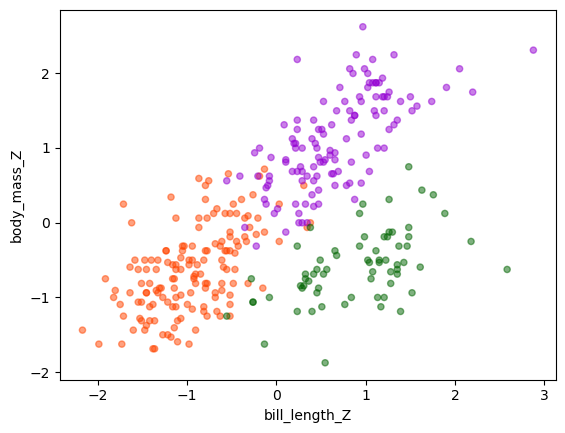

In [7]:
X_vars = ['bill_length_Z', 'body_mass_Z']
y_var = 'species'

# 必要なデータを取り出し，欠損値 (NaN) を含む行を削除
df = df_penguins[X_vars + [y_var]].dropna()

X = df[X_vars]
y = df[y_var]

# データフレームの表示
display(df)

# 散布図の表示
color_map = {'Adelie':'orangered', 'Chinstrap':'darkgreen', 'Gentoo':'darkviolet'}
_ = df.plot.scatter(
    x=X_vars[0], y=X_vars[1],
    c=df[y_var].replace(color_map),
    alpha=0.5,
)

-   <span style="background-color: orangered">　</span> Adelie（アデリーペンギン）   
-   <span style="background-color: darkgreen">　</span> Chinstrap（ヒゲペンギン）   
-   <span style="background-color: darkviolet">　</span> Gentoo（ジェンツーペンギン）   

### クラスタリングの実行
ペンギンの種類 (species) のデータ抜きで，各ペンギンを3つのクラスターに分けてみる  
クラスタリングの手法にはさまざまなものがあるが，ここでは以下の3通りの方法でクラスタリングを行う．
- <span style="color:forestgreen;border-bottom:solid 1px;">k-平均 (k-means) 法</span>　―　非階層的クラスタリング
- <span style="color:forestgreen;border-bottom:solid 1px;">ウォード (Ward) 法</span>　―　階層的クラスタリング
- (おまけ) 混合正規分布モデル (混合ガウスモデル; Gaussian mixture model; GMM) 
  - 各クラスタが正規分布になるという仮定の下で，もっとも誤差の少ないクラスタリングを推定する非階層的クラスタリング

In [8]:
# クラスタリングの実行 (クラスターは番号で示される)

# KMeans の memory leak の回避
import os
os.environ['OMP_NUM_THREADS'] = '2'

# K-means 法
from sklearn.cluster import KMeans
kmeans = KMeans(3, random_state=0).fit(X)

# ウォード (Ward) 法
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(3).fit(X)

# 混合正規分布モデル (GMM)
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(3, random_state=0).fit(X)

# 結果の列をデータに追加
df['kmeans'] = kmeans.predict(X)
df['ward'] = ward.labels_
df['gmm'] = gmm.predict(X)

# 表示
display(df)

c:\ProgramData\Miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\Miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,bill_length_Z,body_mass_Z,species,kmeans,ward,gmm
0,-0.884499,-0.564142,Adelie,2,1,2
1,-0.811126,-0.501703,Adelie,2,1,2
2,-0.664380,-1.188532,Adelie,2,1,2
4,-1.324737,-0.938776,Adelie,2,1,2
5,-0.847812,-0.689020,Adelie,2,1,2
...,...,...,...,...,...,...
339,2.178824,-0.251947,Chinstrap,1,0,1
340,-0.077396,-1.001215,Chinstrap,2,1,1
341,1.041543,-0.532923,Chinstrap,1,0,1
342,1.261662,-0.127069,Chinstrap,1,0,1


-  クラスタ番号をペンギンの種類の名前に付け替える
    -   #142 は Adelie，#307 は Chinstrap，#169 は Gentoo と仮定する（場当たり的ですが……）

In [9]:
# クラスタ番号を名前に付け替え
df.replace({
    'kmeans':{  # kmeans の列での付け換え
        df.loc[142, 'kmeans']:'Adelie', 
        df.loc[307, 'kmeans']:'Chinstrap', 
        df.loc[169, 'kmeans']:'Gentoo'},
    'ward':{    # ward の列での付け換え
        df.loc[142, 'ward']:'Adelie', 
        df.loc[307, 'ward']:'Chinstrap', 
        df.loc[169, 'ward']:'Gentoo'},
    'gmm':{     # gmm の列での付け換え
        df.loc[142, 'gmm']:'Adelie', 
        df.loc[307, 'gmm']:'Chinstrap', 
        df.loc[169, 'gmm']:'Gentoo'}}, inplace=True)

display(df)

,bill_length_Z,body_mass_Z,species,kmeans,ward,gmm
0,-0.884499,-0.564142,Adelie,Adelie,Adelie,Adelie
1,-0.811126,-0.501703,Adelie,Adelie,Adelie,Adelie
2,-0.664380,-1.188532,Adelie,Adelie,Adelie,Adelie
4,-1.324737,-0.938776,Adelie,Adelie,Adelie,Adelie
5,-0.847812,-0.689020,Adelie,Adelie,Adelie,Adelie
...,...,...,...,...,...,...
339,2.178824,-0.251947,Chinstrap,Chinstrap,Chinstrap,Chinstrap
340,-0.077396,-1.001215,Chinstrap,Adelie,Adelie,Chinstrap
341,1.041543,-0.532923,Chinstrap,Chinstrap,Chinstrap,Chinstrap
342,1.261662,-0.127069,Chinstrap,Chinstrap,Chinstrap,Chinstrap


### 結果の評価
混同行列，正解率，散布図

[[143   4   4]
 [  6  61   1]
 [  3  15 105]]	kmeans 正解率: 90.4 %
[[114  37   0]
 [  5  62   1]
 [  0  75  48]]	  ward 正解率: 65.5 %
[[136   4  11]
 [  4  63   1]
 [  2   1 120]]	   gmm 正解率: 93.3 %


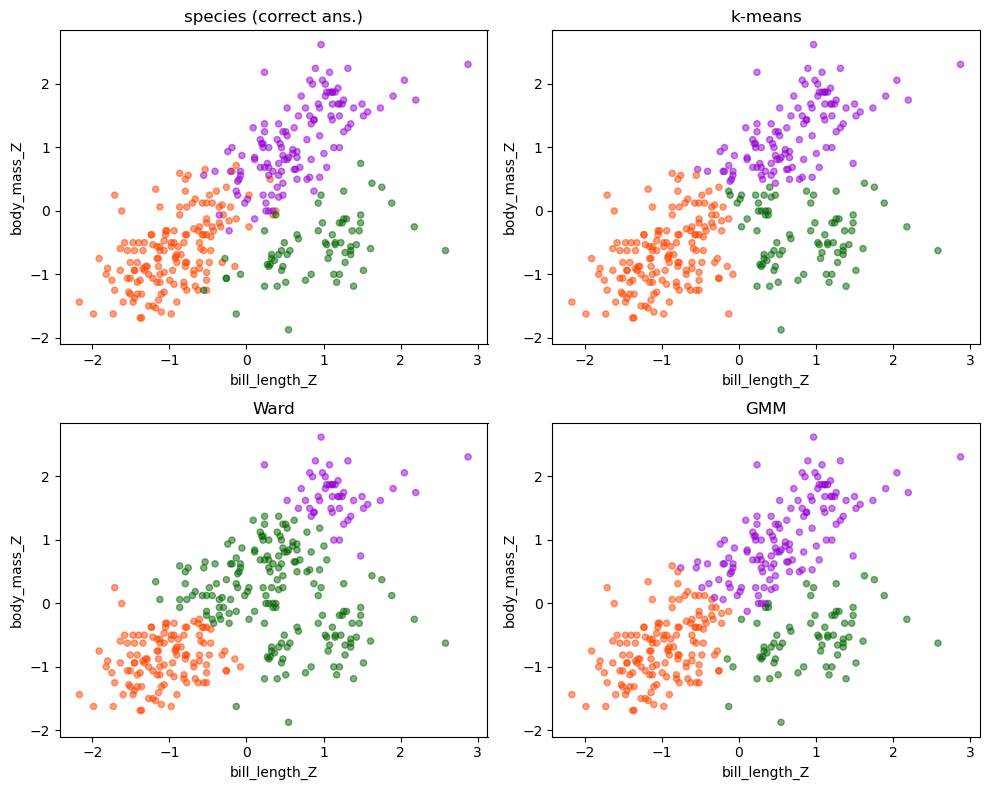

In [10]:
# 混同行列と正解率
from sklearn.metrics import confusion_matrix
print(confusion_matrix(df["species"], df["kmeans"]), end='\t')
print('kmeans 正解率:', round(100*len(df[df['species']==df['kmeans']])/len(df), 1), "%")
print(confusion_matrix(df["species"], df["ward"]), end='\t')
print('  ward 正解率:', round(100*len(df[df['species']==df['ward']])/len(df), 1), "%")
print(confusion_matrix(df["species"], df["gmm"]), end='\t')
print('   gmm 正解率:', round(100*len(df[df['species']==df['gmm']])/len(df), 1), "%")

# 散布図の表示

# サブプロットを作成
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# 各サブプロットに散布図を描画
color_map = {'Adelie':'orangered', 'Chinstrap':'darkgreen', 'Gentoo':'darkviolet'}
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['species'].replace(color_map), alpha=0.5, title='species (correct ans.)',
    ax=axes[0, 0])
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['kmeans'].replace(color_map), alpha=0.5, title='k-means',
    ax=axes[0, 1])
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['ward'].replace(color_map), alpha=0.5, title='Ward',
    ax=axes[1, 0])
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['gmm'].replace(color_map), alpha=0.5, title='GMM',
    ax=axes[1, 1])

plt.tight_layout()  # グラフ同士が重ならないように調整
plt.show()

## 〔参考〕正規化しなかった場合のクラスタリング
-  上と同様に「くちばしの長さ」と「体重」を用いるが，正規化する前の値 (bill_length_mm，body_mass_g) でクラスタリングを行ってみる
### 使用変数の抽出

In [11]:
X_vars = ['bill_length_mm', 'body_mass_g']
y_var = 'species'

# 必要なデータを取り出し，欠損値 (NaN) を含む行を削除
df2 = df_penguins[X_vars + [y_var]].dropna()

X = df2[X_vars]
y = df2[y_var]

# データフレームの表示
display(df2)

#  散布図の表示（省略）
# color_map = {'Adelie':'orangered', 'Chinstrap':'darkgreen', 'Gentoo':'darkviolet'}
# _ = df.plot.scatter(
#     x=X_vars[0], y=X_vars[1],
#     c=df[y_var].replace(color_map),
#     alpha=0.5,
# )

,bill_length_mm,body_mass_g,species
0,39.1,3750.0,Adelie
1,39.5,3800.0,Adelie
2,40.3,3250.0,Adelie
4,36.7,3450.0,Adelie
5,39.3,3650.0,Adelie
...,...,...,...
339,55.8,4000.0,Chinstrap
340,43.5,3400.0,Chinstrap
341,49.6,3775.0,Chinstrap
342,50.8,4100.0,Chinstrap


### クラスタリングの実行

In [12]:
# クラスタリングの実行 (クラスターは番号で示される)

# KMeans の memory leak の回避
import os
os.environ['OMP_NUM_THREADS'] = '2'

# K-means 法
from sklearn.cluster import KMeans
kmeans = KMeans(3, random_state=0).fit(X)

# ウォード (Ward) 法
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(3).fit(X)

# 混合正規分布モデル (GMM)
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(3, random_state=0).fit(X)

# 結果の列をデータに追加
df2['kmeans'] = kmeans.predict(X)
df2['ward'] = ward.labels_
df2['gmm'] = gmm.predict(X)

# 表示
# display(df2)

# クラスタ番号を名前に付け替え
# #142 は Adelie，#307 は Chinstrap，#169 は Gentoo と仮定する（場当たり的ですが……）
df2.replace({
    'kmeans':{  # kmeans の列での付け換え
        df2.loc[142, 'kmeans']:'Adelie', 
        df2.loc[307, 'kmeans']:'Chinstrap', 
        df2.loc[169, 'kmeans']:'Gentoo'},
    'ward':{    # ward の列での付け換え
        df2.loc[142, 'ward']:'Adelie', 
        df2.loc[307, 'ward']:'Chinstrap', 
        df2.loc[169, 'ward']:'Gentoo'},
    'gmm':{     # gmm の列での付け換え
        df2.loc[142, 'gmm']:'Adelie', 
        df2.loc[307, 'gmm']:'Chinstrap', 
        df2.loc[169, 'gmm']:'Gentoo'}}, inplace=True)

display(df2)

c:\ProgramData\Miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\Miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,bill_length_mm,body_mass_g,species,kmeans,ward,gmm
0,39.1,3750.0,Adelie,Adelie,Adelie,Adelie
1,39.5,3800.0,Adelie,Adelie,Adelie,Adelie
2,40.3,3250.0,Adelie,Adelie,Adelie,Adelie
4,36.7,3450.0,Adelie,Adelie,Adelie,Adelie
5,39.3,3650.0,Adelie,Adelie,Adelie,Adelie
...,...,...,...,...,...,...
339,55.8,4000.0,Chinstrap,Chinstrap,Chinstrap,Chinstrap
340,43.5,3400.0,Chinstrap,Adelie,Adelie,Chinstrap
341,49.6,3775.0,Chinstrap,Adelie,Adelie,Chinstrap
342,50.8,4100.0,Chinstrap,Chinstrap,Chinstrap,Chinstrap


### 結果の評価
混同行列，正解率，散布図

[[98 53  0]
 [46 22  0]
 [ 0 42 81]]	kmeans 正解率: 58.8 %
[[97 54  0]
 [45 23  0]
 [ 0 65 58]]	  ward 正解率: 52.0 %
[[139   1  11]
 [  4  61   3]
 [  2   0 121]]	   gmm 正解率: 93.9 %


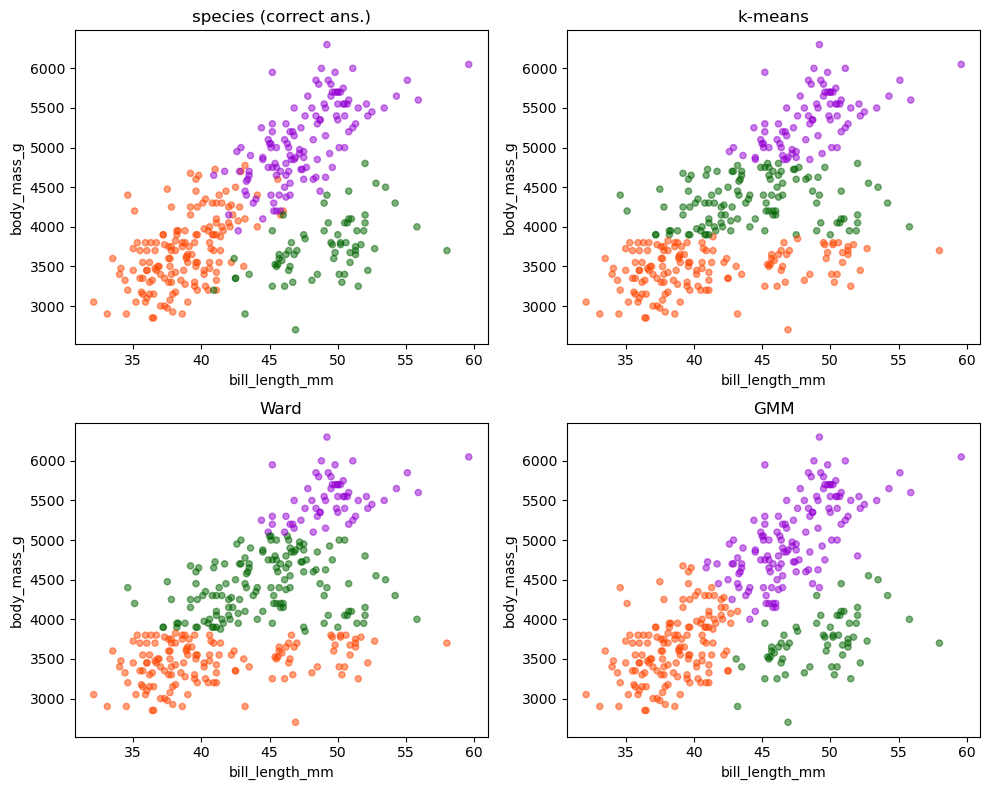

In [13]:
# 混同行列と正解率
from sklearn.metrics import confusion_matrix
print(confusion_matrix(df2["species"], df2["kmeans"]), end='\t')
print('kmeans 正解率:', round(100*len(df2[df2['species']==df2['kmeans']])/len(df2), 1), "%")
print(confusion_matrix(df2["species"], df2["ward"]), end='\t')
print('  ward 正解率:', round(100*len(df2[df2['species']==df2['ward']])/len(df2), 1), "%")
print(confusion_matrix(df2["species"], df2["gmm"]), end='\t')
print('   gmm 正解率:', round(100*len(df2[df2['species']==df2['gmm']])/len(df2), 1), "%")

# 散布図の表示

# サブプロットを作成
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# 各サブプロットに散布図を描画
color_map = {'Adelie':'orangered', 'Chinstrap':'darkgreen', 'Gentoo':'darkviolet'}
df2.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df2['species'].replace(color_map), alpha=0.5, title='species (correct ans.)',
    ax=axes[0, 0])
df2.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df2['kmeans'].replace(color_map), alpha=0.5, title='k-means',
    ax=axes[0, 1])
df2.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df2['ward'].replace(color_map), alpha=0.5, title='Ward',
    ax=axes[1, 0])
df2.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df2['gmm'].replace(color_map), alpha=0.5, title='GMM',
    ax=axes[1, 1])

plt.tight_layout()  # グラフ同士が重ならないように調整
plt.show()